In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

orders = pd.read_csv(r"C:\Users\admin\Desktop\EcommerceProject_2\orders.csv")
customers = pd.read_csv(r"C:\Users\admin\Desktop\EcommerceProject_2\customers.csv")
products = pd.read_csv(r"C:\Users\admin\Desktop\EcommerceProject_2\products.csv")

df = pd.merge(orders, customers, on='Customer_ID', how='left') #left joining the orders with customers on Customer_ID
df = pd.merge(df, products, on='Product_ID', how='left') #left joining products with the existing df on Product_ID

df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Price,Name,Age,Gender,City,Signup_Date,Category,Sub_Category,Cost,Selling_Price
0,2000,2024-01-01,1062,5030,3,28,1988.16,Customer_62,27,Female,Mumbai,2023-03-04,Home,Mobile,648.99,1988.16
1,2001,2024-01-02,1188,5055,3,3,1389.80,Customer_188,49,Male,Chennai,2023-07-08,Clothing,Laptop,353.94,1389.80
2,2002,2024-01-03,1048,5078,1,4,4391.69,Customer_48,52,Female,Chennai,2023-02-18,Electronics,Laptop,2914.92,4391.69
3,2003,2024-01-04,1256,5072,3,10,627.14,Customer_256,41,Male,Delhi,2023-09-14,Electronics,Laptop,709.06,627.14
4,2004,2024-01-05,1223,5086,1,23,1298.68,Customer_223,58,Male,Mumbai,2023-08-12,Home,Mobile,3359.47,1298.68


In [15]:
df.isnull().sum() #checking for missing data

Order_ID         0
Order_Date       0
Customer_ID      0
Product_ID       0
Quantity         0
Discount         0
Price            0
Name             0
Age              0
Gender           0
City             0
Signup_Date      0
Category         0
Sub_Category     0
Cost             0
Selling_Price    0
dtype: int64

In [16]:
df['Revenue'] = df['Quantity'] * df['Price'] * (1 - df['Discount']/100) #creating a revenue column
df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Price,Name,Age,Gender,City,Signup_Date,Category,Sub_Category,Cost,Selling_Price,Revenue
0,2000,2024-01-01,1062,5030,3,28,1988.16,Customer_62,27,Female,Mumbai,2023-03-04,Home,Mobile,648.99,1988.16,4294.4256
1,2001,2024-01-02,1188,5055,3,3,1389.80,Customer_188,49,Male,Chennai,2023-07-08,Clothing,Laptop,353.94,1389.80,4044.3180
2,2002,2024-01-03,1048,5078,1,4,4391.69,Customer_48,52,Female,Chennai,2023-02-18,Electronics,Laptop,2914.92,4391.69,4216.0224
3,2003,2024-01-04,1256,5072,3,10,627.14,Customer_256,41,Male,Delhi,2023-09-14,Electronics,Laptop,709.06,627.14,1693.2780
4,2004,2024-01-05,1223,5086,1,23,1298.68,Customer_223,58,Male,Mumbai,2023-08-12,Home,Mobile,3359.47,1298.68,999.9836


In [17]:
df['Order_Date'] = pd.to_datetime(df['Order_Date']) #converting format to datetime
df['Month'] = df['Order_Date'].dt.month #creating month column
df['Year'] = df['Order_Date'].dt.year #creating year column

In [18]:
df.describe() #statistical summary

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Price,Age,Cost,Selling_Price,Revenue,Month,Year
count,1000.000000,1000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2499.500000,2025-05-14 12:00:00,1148.926000,5048.487000,2.48600,15.01400,4195.400210,39.100000,2492.279700,4195.400210,8974.599524,6.100000,2024.903000
min,2000.000000,2024-01-01 00:00:00,1000.000000,5000.000000,1.00000,0.00000,236.130000,18.000000,353.940000,236.130000,191.265300,1.000000,2024.000000
25%,2249.750000,2024-09-06 18:00:00,1072.750000,5022.000000,1.00000,7.00000,2631.430000,28.000000,1305.190000,2631.430000,3476.014900,3.000000,2024.000000
50%,2499.500000,2025-05-14 12:00:00,1149.500000,5048.000000,2.00000,15.00000,4391.690000,40.000000,2457.590000,4391.690000,7308.437450,6.000000,2025.000000
75%,2749.250000,2026-01-19 06:00:00,1225.250000,5074.000000,4.00000,23.00000,5965.077500,50.000000,3731.490000,5965.077500,13107.612900,9.000000,2026.000000
max,2999.000000,2026-09-26 00:00:00,1299.000000,5099.000000,4.00000,29.00000,7881.760000,59.000000,4950.810000,7881.760000,30169.692000,12.000000,2026.000000
std,288.819436,NaN,88.395816,29.105617,1.13185,8.76862,2171.120684,12.251371,1351.843836,2171.120684,6655.465263,3.307407,0.791339


In [19]:
df['Revenue'].sum() #total revenue of the business

np.float64(8974599.5236)

In [21]:
df.groupby('Category')['Revenue'].sum().sort_values(ascending=False) #top performing categories

Category
Clothing       3.250509e+06
Home           2.925302e+06
Electronics    2.798788e+06
Name: Revenue, dtype: float64

In [22]:
df.groupby('Sub_Category')['Revenue'].sum().sort_values(ascending=False) #top performing products

Sub_Category
Laptop       2.694931e+06
Shirt        2.531747e+06
Mobile       2.056019e+06
Furniture    1.691903e+06
Name: Revenue, dtype: float64

In [23]:
df.groupby('City')['Revenue'].sum().sort_values(ascending=False) #top performing cities

City
Delhi        2.612750e+06
Mumbai       2.163544e+06
Chennai      2.101543e+06
Bangalore    2.096763e+06
Name: Revenue, dtype: float64

In [24]:
df.groupby(['Year','Month'])['Revenue'].sum() #monthly trend

Year  Month
2024  1        217825.6058
      2        317648.8590
      3        317723.4620
      4        255606.6068
      5        229074.1430
      6        264843.6508
      7        315712.5972
      8        279673.8445
      9        289004.6465
      10       311900.5853
      11       267833.8136
      12       256482.2822
2025  1        301355.2756
      2        264236.0824
      3        277132.0715
      4        267824.0137
      5        342178.1501
      6        247200.4385
      7        291781.6342
      8        279873.9336
      9        245148.1757
      10       267809.2262
      11       290171.2911
      12       253446.1614
2026  1        319986.0375
      2        225199.3054
      3        277280.3794
      4        289526.3414
      5        267048.9592
      6        211137.7412
      7        276255.4442
      8        245196.5908
      9        211482.1738
Name: Revenue, dtype: float64

In [25]:
df.groupby(['Year','Month'])['Revenue'].sum().sort_values(ascending=False).head(10) #top ten best performing months

Year  Month
2025  5        342178.1501
2026  1        319986.0375
2024  3        317723.4620
      2        317648.8590
      7        315712.5972
      10       311900.5853
2025  1        301355.2756
      7        291781.6342
      11       290171.2911
2026  4        289526.3414
Name: Revenue, dtype: float64

In [26]:
df.groupby('Customer_ID')['Revenue'].sum().sort_values(ascending=False).head(10) #top customers

Customer_ID
1292    129971.9390
1011    117351.1730
1263     96446.4065
1250     91975.7948
1116     85243.5824
1223     85032.9346
1101     79782.7928
1153     79391.4735
1142     79215.3750
1214     77884.7529
Name: Revenue, dtype: float64

In [27]:
df.groupby('Customer_ID')['Order_ID'].count().sort_values(ascending=False).head(10) #top ten repeat customers

Customer_ID
1011    12
1292    11
1129     9
1287     9
1263     8
1157     8
1225     8
1072     7
1160     7
1024     7
Name: Order_ID, dtype: int64

In [28]:
df.groupby(['Year'])['Revenue'].sum().sort_values(ascending=False) #years ranked by performance

Year
2025    3.328156e+06
2024    3.323330e+06
2026    2.323113e+06
Name: Revenue, dtype: float64

In [29]:
df.groupby('Category')['Discount'].mean().sort_values(ascending=False) #categories with the highest discounts

Category
Home           15.087464
Clothing       15.044510
Electronics    14.903125
Name: Discount, dtype: float64

In [30]:
df['Profit'] = df['Price'] - df['Cost'] #creating a profit column
df.groupby('Sub_Category')['Profit'].mean().sort_values(ascending=False).head(10) #top ten high margin products

Sub_Category
Furniture    2725.993043
Laptop       1849.157817
Shirt        1627.167283
Mobile       1082.306711
Name: Profit, dtype: float64

In [31]:
df.groupby('Sub_Category')['Price'].mean().sort_values(ascending=False) #sorting products by price

Sub_Category
Furniture    4666.722236
Shirt        4652.021850
Laptop       4449.925810
Mobile       3317.825415
Name: Price, dtype: float64

In [32]:
df[df['Revenue'] > df['Revenue'].mean()] #products that generate more than average revenue

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Price,Name,Age,Gender,City,Signup_Date,Category,Sub_Category,Cost,Selling_Price,Revenue,Month,Year,Profit
5,2005,2024-01-06,1140,5082,3,18,5952.51,Customer_140,53,Male,Mumbai,2023-05-21,Clothing,Shirt,1087.97,5952.51,14643.1746,1,2024,4864.54
11,2011,2024-01-12,1285,5061,3,18,7419.43,Customer_285,50,Female,Mumbai,2023-10-13,Home,Laptop,4068.38,7419.43,18251.7978,1,2024,3351.05
12,2012,2024-01-13,1143,5006,3,12,5096.12,Customer_143,24,Female,Bangalore,2023-05-24,Clothing,Shirt,2975.52,5096.12,13453.7568,1,2024,2120.60
17,2017,2024-01-18,1174,5003,2,6,5069.06,Customer_174,49,Female,Mumbai,2023-06-24,Electronics,Mobile,2542.37,5069.06,9529.8328,1,2024,2526.69
18,2018,2024-01-19,1193,5039,4,25,7285.91,Customer_193,43,Female,Mumbai,2023-07-13,Electronics,Furniture,2828.14,7285.91,21857.7300,1,2024,4457.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,2985,2026-09-12,1019,5002,3,20,7270.48,Customer_19,55,Male,Mumbai,2023-01-20,Home,Laptop,3966.94,7270.48,17449.1520,9,2026,3303.54
987,2987,2026-09-14,1159,5069,3,14,4246.94,Customer_159,44,Male,Delhi,2023-06-09,Clothing,Shirt,4654.69,4246.94,10957.1052,9,2026,-407.75
992,2992,2026-09-19,1150,5002,2,17,7270.48,Customer_150,45,Male,Mumbai,2023-05-31,Home,Laptop,3966.94,7270.48,12068.9968,9,2026,3303.54
995,2995,2026-09-22,1265,5039,2,24,7285.91,Customer_265,52,Male,Bangalore,2023-09-23,Electronics,Furniture,2828.14,7285.91,11074.5832,9,2026,4457.77


In [33]:
df.groupby('Category')['Age'].mean() #average age for each category

Category
Clothing       38.255193
Electronics    39.268750
Home           39.772595
Name: Age, dtype: float64

In [34]:
df.groupby('Gender')['Order_ID'].count() #order counts by gender

Gender
Female    530
Male      470
Name: Order_ID, dtype: int64

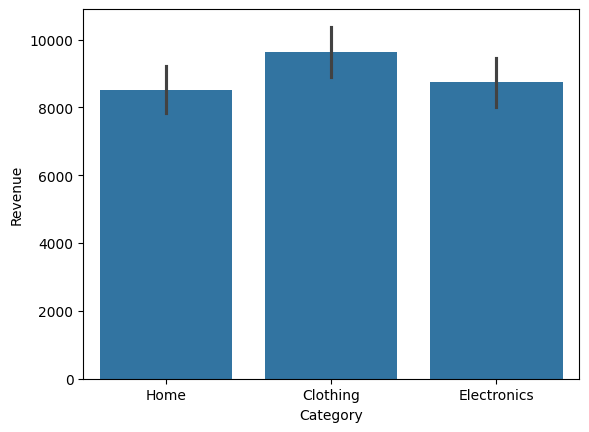

In [35]:
sns.barplot(x='Category', y='Revenue', data=df) #revenue by category bar graph
plt.show()

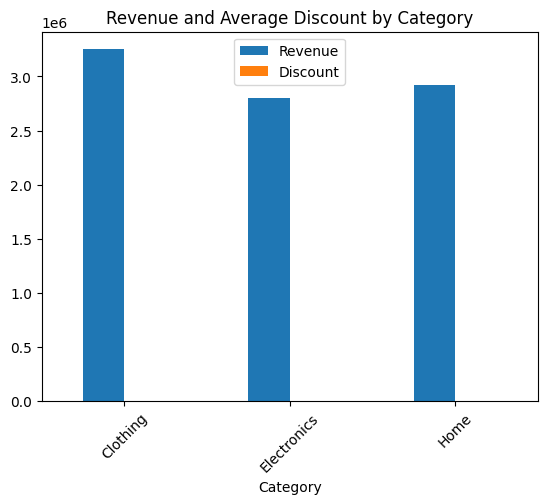

In [36]:
df.groupby('Category').agg({
    'Revenue': 'sum',
    'Discount': 'mean'
}).plot(kind='bar')

plt.title("Revenue and Average Discount by Category") #revenue and average discount bar chart
plt.xticks(rotation=45)
plt.show()

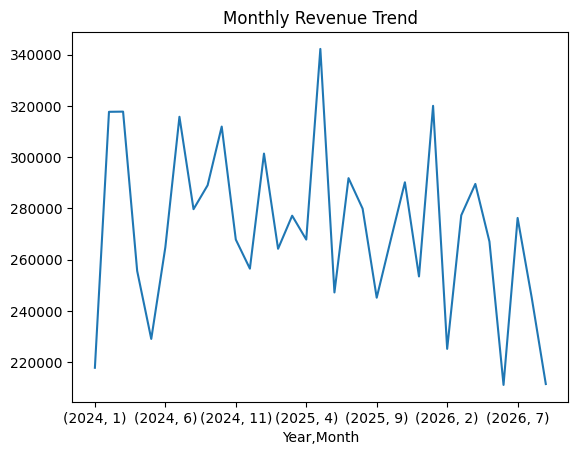

In [37]:
df.groupby(['Year','Month'])['Revenue'].sum().plot() #monthly revenue trend in a line chart
plt.title("Monthly Revenue Trend")
plt.show()

In [38]:
rfm = df.groupby('Customer_ID').agg({ #creating rfm dataframe
    'Order_Date': lambda x: (df['Order_Date'].max() - x.max()).days,
    'Order_ID': 'count',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
1000,303,3,9756.9678
1001,223,4,9414.7900
1002,95,5,54156.2198
1003,429,4,18179.4330
1004,5,5,19748.7926


In [37]:
rfm['Segment'] = 'Medium'
rfm.loc[(rfm['Recency'] <= 30) & (rfm['Frequency'] >= 5) & (rfm['Monetary'] > rfm['Monetary'].median()), 'Segment'] = 'High Value'
rfm.loc[(rfm['Recency'] > 60) & (rfm['Frequency'] <= 2), 'Segment'] = 'Low Value'
rfm['Segment'].value_counts()

Segment
Medium        180
Low Value      97
High Value     13
Name: count, dtype: int64

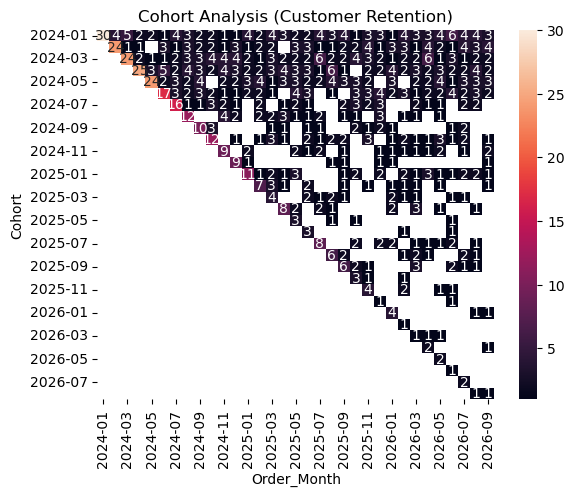

In [39]:
df['Cohort'] = df.groupby('Customer_ID')['Order_Date'].transform('min').dt.to_period('M')
df['Order_Month'] = df['Order_Date'].dt.to_period('M')
cohort_data = df.groupby(['Cohort', 'Order_Month'])['Customer_ID'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='Cohort', columns='Order_Month', values='Customer_ID')

sns.heatmap(cohort_pivot, annot=True, fmt=".0f")
plt.title("Cohort Analysis (Customer Retention)")
plt.show()

First-time customers: 31
Repeat customers: 259


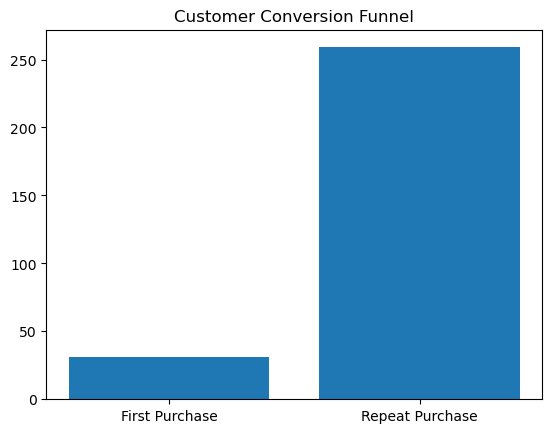

In [40]:
customer_orders = df.groupby('Customer_ID')['Order_ID'].count()
first_time = (customer_orders == 1).sum()
repeat = (customer_orders > 1).sum()

print("First-time customers:", first_time)
print("Repeat customers:", repeat)

stages = ['First Purchase', 'Repeat Purchase']
values = [first_time, repeat]

plt.bar(stages, values)
plt.title("Customer Conversion Funnel")
plt.show()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Price,Name,Age,Gender,...,Category,Sub_Category,Cost,Selling_Price,Revenue,Month,Year,Profit,Cohort,Order_Month
0,2000,2024-01-01,1062,5030,3,28,1988.16,Customer_62,27,Female,...,Home,Mobile,648.99,1988.16,4294.4256,1,2024,1339.17,2024-01,2024-01
1,2001,2024-01-02,1188,5055,3,3,1389.80,Customer_188,49,Male,...,Clothing,Laptop,353.94,1389.80,4044.3180,1,2024,1035.86,2024-01,2024-01
2,2002,2024-01-03,1048,5078,1,4,4391.69,Customer_48,52,Female,...,Electronics,Laptop,2914.92,4391.69,4216.0224,1,2024,1476.77,2024-01,2024-01
3,2003,2024-01-04,1256,5072,3,10,627.14,Customer_256,41,Male,...,Electronics,Laptop,709.06,627.14,1693.2780,1,2024,-81.92,2024-01,2024-01
4,2004,2024-01-05,1223,5086,1,23,1298.68,Customer_223,58,Male,...,Home,Mobile,3359.47,1298.68,999.9836,1,2024,-2060.79,2024-01,2024-01


In [45]:
rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_data)

rfm.head(10)

,Recency,Frequency,Monetary,Segment,Cluster
Customer_ID,,,,,
1000,303,3,9756.9678,Medium,0
1001,223,4,9414.7900,Medium,0
1002,95,5,54156.2198,Medium,1
1003,429,4,18179.4330,Medium,0
1004,5,5,19748.7926,Medium,0
1006,47,6,46570.3984,Medium,1
1007,321,4,44204.4367,Medium,1
1008,199,6,68575.3863,Medium,2
1009,197,2,30708.0144,Low Value,1


In [48]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,342.496350,2.277372,14028.125981
1,233.425000,3.941667,38411.479393
2,139.090909,6.515152,74041.476879


In [8]:
df_sorted = df.sort_values('Order_Date')
revenue_series = df_sorted.groupby('Order_Date')['Revenue'].sum()

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(revenue_series, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)
print(forecast)

C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2026-09-27    8865.786645
2026-09-28    8963.792089
2026-09-29    8965.535986
2026-09-30    8965.567017
2026-10-01    8965.567569
Freq: D, Name: predicted_mean, dtype: float64


In [11]:
basket = df.groupby(['Order_ID', 'Sub_Category'])['Quantity'].sum().unstack().fillna(0)

basket = (basket > 0)

from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(basket, min_support=0.005, use_colnames=True)

rules = association_rules(frequent_items, metric="lift", min_threshold=1)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift


In [39]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)
rfm.to_csv("rfm_customer_data.csv")